In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)



comp = pd.read_csv("data/comp trial 1.csv", low_memory=False)
fjc = pd.read_csv("data/fjc trial 1.csv", low_memory=False)

#print(comp.shape, fjc.shape)
#print(comp.head())
#print(fjc.head())

In [2]:
comp["datadate"] = pd.to_datetime(comp["datadate"], dayfirst=True, errors="coerce")
fjc["FILEDATE"] = pd.to_datetime(fjc["FILEDATE"], dayfirst=True, errors="coerce")
#comp["datadate"].head()

In [3]:
comp = comp[(comp["datadate"] >= "2000-01-01") & (comp["datadate"] <= "2018-12-31")]
fjc = fjc[(fjc["FILEDATE"] >= "2000-01-01") & (fjc["FILEDATE"] <= "2019-12-31")]

In [4]:
comp["cik"] = pd.to_numeric(comp["cik"], errors="coerce")
fjc["cik"] = pd.to_numeric(fjc["cik"], errors="coerce")

comp = comp.dropna(subset=["cik"]).copy()
fjc = fjc.dropna(subset=["cik"]).copy()

comp["cik"] = comp["cik"].astype(int)
fjc["cik"] = fjc["cik"].astype(int)

merged = comp.merge(fjc[["cik", "FILEDATE"]], on="cik", how="left")
#merge comp and add the cik and filedate columns for all shared cik values, using a left join to keep all rows from comp and add matching rows from fjc.
merged["days"] = (merged["FILEDATE"] - merged["datadate"]).dt.days
#calculate a new column "days" that shows the difference in days between the filiing date (bankruptcy) and the datadate (company's fisical year end date). 
#Positive days means the filing date is after the data date; negative means it's before.
merged["distress"] = ((merged["days"] > 0) & (merged["days"] <= 365)).astype(int)
#create a new column "distress" that is True (1) if both conditions are met: the filing date is after the data date and within 365 days, otherwise False (0).
merged.loc[merged["FILEDATE"].isna(), "distress"] = 0
#set distress to 0 for rows where FILEDATE is NaN, meaning there is no filing date available.
#loc is used here to acess the filedate column and then check (.isna()) if the value is NaN (returns True), and then explicitly sets the distress to 0. 
#Under the assumption that the data is not missing , we can assume that if there is no filing date, the company did not file for bankruptcy within the year after the datadate.
merged_clean = merged.groupby(["gvkey", "datadate"], as_index=False).agg(distress=("distress", "max"))
#this line groups the merged dataframe which has comp and fjc data merged by cik and datadate, as well as the days and distress columns( all previous commands), and groups rows into bucket (groupby) by shared gvkey and datadate values, and then aggregates the distress column by taking the maximum value for each group. This is done to ensure that if there are multiple rows for the same gvkey and datadate (redudant), we only keep one row with the highest distress value (1 if any of the rows had distress, otherwise 0). The as_index=False argument ensures that gvkey and datadate remain as columns in the resulting dataframe rather than being set as the index.
final = comp.merge(merged_clean, on=["gvkey", "datadate"], how="left")
# now we merge again to the final dataframe,  which is comp + merged+ merged_clean, to add the distress column to the og dataframe, using a left join to keep all rows from comp and add matching rows from merged_clean.
final["distress"] = final["distress"].fillna(0).astype(int)
#change all NaN values in the distress column to 0 , and convert the column to integer type, since the column after .fillna() will be float type due to the presence of NaN values.

print(len(comp), len(final))
#should be the same length , a check we didnot lose any rows in the final merge.
print(final["distress"].value_counts())
final["year"] = final["datadate"].dt.year
print(final.groupby("year")["distress"].sum())
#This is for deciding how to split the data into training and testing sets. We want to make sure that we have enough positive cases of distress in the training set to train the model effectively. If we have too few positive cases, the model may not learn to identify distress effectively, leading to poor performance on the test set.


195302 195302
distress
0    195050
1       252
Name: count, dtype: int64
year
2000     1
2001     3
2002     1
2003     0
2004     8
2005     3
2006    13
2007    26
2008    26
2009    17
2010    24
2011    23
2012    14
2013    18
2014    16
2015    25
2016    16
2017    13
2018     5
Name: distress, dtype: int64


In [5]:
print(final["datadate"].min(), final["datadate"].max())
print(final["year"].min(), final["year"].max())
print(final.groupby("year").size())  # all firm-years per year, not just distress

2000-01-31 00:00:00 2018-12-31 00:00:00
2000 2018
year
2000    12154
2001    11692
2002    11434
2003    11230
2004    10969
2005    10814
2006    10535
2007    10205
2008     9894
2009     9769
2010     9744
2011     9785
2012    10060
2013    10116
2014     9846
2015     9524
2016     9381
2017     9148
2018     9002
dtype: int64


In [6]:
#Checking categorical metadata variables in order to filter the data to only include the relevant firms.
print(final["consol"].value_counts(dropna=False)) 
print()
print(final["indfmt"].value_counts(dropna=False))
print()
print(final["datafmt"].value_counts(dropna=False))
print()
print(final["curcd"].value_counts(dropna=False))
print()
print(final["costat"].value_counts(dropna=False))

consol
C    195302
Name: count, dtype: int64

indfmt
INDL    172673
FS       22629
Name: count, dtype: int64

datafmt
STD    195302
Name: count, dtype: int64

curcd
USD    179833
CAD     15469
Name: count, dtype: int64

costat
I    102188
A     93114
Name: count, dtype: int64


In [7]:
#For the metadata variables, we want to filter the data to only include firms that are eligible for analysis
final = final[final["indfmt"] == "INDL"] #limiting to industrial format firms, which are the most common type of firms in the dataset and are more likely to have complete financial data.
final = final[final["curcd"] == "USD"] #limiting to firms that report in USD, so that we can compare financial data across firms without having to worry about currency conversion.
# we keep both I and A values for the costat column, since we want to include both active and inactive firms in the analysis.

 
#Creating the ratios to avoid multicollinearity issues
final["working_capital"]= (final["act"] - final["lct"])/final["at"]
final["leverage"]= final["lt"]/final["at"]
final["debt_maturity"] = (final["dlc"]/(final["dlc"]+final["dltt"]))
final["profitability"] = final["ebit"]/final["at"]
final["cash_flow_profitability"] = final["oancf"]/final["at"]
final["retained_earnings"] = final["re"]/final["at"]
final["asset_turnover"] = final["sale"]/final["at"]
final["interest_burden"] = final["xint"]/final["at"]
final["investment_intensity"] = final["capx"]/final["at"]
final["sga_intensity"] = final["xsga"]/final["sale"]
final["market_scaling"] = final["mkvalt"]/final["at"]

''' 
Optional - will add only if they improve validation , otherwise kept them commented out
final["cash_holdings"] = final["che"]/final["at"]
final["asset_tangibility"] = final["ppent"]/final["at"]
final["receivables_intensity"] = final["rect"]/final["sale"]
final["inventory_intensity"] = final["invt"]/final["sale"]
''' 

print(final.columns.tolist())

['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate', 'gvkey', 'conm', 'cik', 'fyr', 'fic', 'loc', 'sic', 'act', 'at', 'ceq', 'che', 'dlc', 'dltt', 'invt', 'lct', 'lt', 'ppent', 're', 'rect', 'seq', 'ebit', 'ni', 'sale', 'xint', 'xsga', 'capx', 'oancf', 'mkvalt', 'distress', 'year', 'working_capital', 'leverage', 'debt_maturity', 'profitability', 'cash_flow_profitability', 'retained_earnings', 'asset_turnover', 'interest_burden', 'investment_intensity', 'sga_intensity', 'market_scaling']


In [8]:
#Looking at the amount of missing values in the features columns
print(final["act"].isna().sum()/len(final))
print(final["at"].isna().sum()/len(final))
print(final["ceq"].isna().sum()/len(final))
print(final["che"].isna().sum()/len(final))
print(final["dlc"].isna().sum()/len(final))
print(final["dltt"].isna().sum()/len(final))
print(final["invt"].isna().sum()/len(final))
print(final["lct"].isna().sum()/len(final))
print(final["lt"].isna().sum()/len(final))
print(final["ppent"].isna().sum()/len(final))
print(final["rect"].isna().sum()/len(final))
print(final["re"].isna().sum()/len(final))
print(final["ebit"].isna().sum()/len(final))
print(final["seq"].isna().sum()/len(final))
print(final["ni"].isna().sum()/len(final))
print(final["sale"].isna().sum()/len(final))
print(final["xint"].isna().sum()/len(final))
print(final["xsga"].isna().sum()/len(final))
print(final["capx"].isna().sum()/len(final))
print(final["oancf"].isna().sum()/len(final))
print(final["mkvalt"].isna().sum()/len(final))


0.2677802542930956
0.09517628286307685
0.09746213464363507
0.0953029228509194
0.09606276277797478
0.09766475862418317
0.10554176586799048
0.264981510561775
0.09675928271110885
0.11938351653918242
0.1013499822704017
0.12522795197811662
0.102996302112355
0.09521427485942961
0.09893115850260878
0.0989564865001773
0.2360759333367104
0.2542234435945494
0.12920444759637303
0.12493034800668659
0.28587077655640547


In [ ]:
'''
features = ["act", "at", "ceq", "che", "dlc", "dltt", "invt", "lct", "lt", 
            "ppent", "rect", "re", "ebit", "seq", "ni", "sale", "xint", 
            "xsga", "capx", "oancf", "mkvalt"]
#Main accounting variables.
''' 
features = [
 "working_capital",
 "leverage",
 "debt_maturity",
 "profitability",
 "cash_flow_profitability",
 "retained_earnings",
 "asset_turnover",
 "interest_burden",
 "investment_intensity",
 "sga_intensity",
 "market_scaling"
]

final.groupby("distress")[features].apply(lambda x: x.isna().mean())
#Some checks to see how many missing values there are in the features columns, grouped by distress.
#final.groupby("distress")[features].apply(lambda x: x.isna().mean().max())
#print(final["distress"].value_counts())



,working_capital,leverage,debt_maturity,profitability,cash_flow_profitability,retained_earnings,asset_turnover,interest_burden,investment_intensity,sga_intensity,market_scaling
distress,,,,,,,,,,,
0,0.268875,0.097395,0.246921,0.103844,0.126368,0.125442,0.103197,0.238957,0.133597,0.255622,0.286066
1,0.095652,0.008696,0.039130,0.013043,0.026087,0.060870,0.008696,0.052174,0.034783,0.152174,0.160870


In [10]:
final[features].isna().sum()

working_capital            42423
leverage                   15361
debt_maturity              38948
profitability              16379
cash_flow_profitability    19934
retained_earnings          19796
asset_turnover             16276
interest_burden            37695
investment_intensity       21076
sga_intensity              40346
market_scaling             45149
dtype: int64

In [11]:
#predictor varaibles and target variable
accounting_features = [
    "working_capital",
    "leverage",
    "debt_maturity",
    "profitability",
    "cash_flow_profitability",
    "retained_earnings",
    "asset_turnover",
    "interest_burden",
    "investment_intensity",
    "sga_intensity",
    "market_scaling"
]

missing_indicator_features = [
    "working_capital_missing",
    "leverage_missing",
    "debt_maturity_missing",
    "profitability_missing",
    "cash_flow_profitability_missing",
    "retained_earnings_missing",
    "asset_turnover_missing",
    "interest_burden_missing",
    "investment_intensity_missing",
    "sga_intensity_missing",
    "market_scaling_missing"
]
x = accounting_features + missing_indicator_features
y = ["distress"] #target

final.groupby("year")["distress"].sum()
final.groupby("year").size()

year
2000    10423
2001     9931
2002     9599
2003     9334
2004     9071
2005     8867
2006     8572
2007     8283
2008     7998
2009     7847
2010     7758
2011     7764
2012     7894
2013     7921
2014     7692
2015     7415
2016     7325
2017     7157
2018     7077
dtype: int64

In [12]:
#Splitting data into train, validation , test dataframes
train = final[final["year"].between(2000, 2010)].copy()
val = final[final["year"].between(2011,2013)].copy()
test = final[final["year"].between(2014,2018)].copy()

x_train = train[x]
y_train = train["distress"]

x_val = val[x]
y_val = val["distress"]

x_test = test[x]
y_test = test["distress"]

#Scaling with standard scaler for LR model only
scaler = StandardScaler()
scaler.fit(x_train[accounting_features])
#copy entire unscaled datasets
X_train_scaled = x_train.copy()
X_val_scaled = x_val.copy()
X_test_scaled = x_test.copy()
#overwrite the accounting variables to the scaled ones
#Now these datasets can be used for logistic regression
X_train_scaled = pd.DataFrame(
    scaler.transform(x_train[accounting_features]),
    columns=accounting_features,
    index=x_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(x_val[accounting_features]),
    columns=accounting_features,
    index=x_val.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(x_test[accounting_features]),
    columns=accounting_features,
    index=x_test.index
)

KeyError: "['working_capital_missing', 'leverage_missing', 'debt_maturity_missing', 'profitability_missing', 'cash_flow_profitability_missing', 'retained_earnings_missing', 'asset_turnover_missing', 'interest_burden_missing', 'investment_intensity_missing', 'sga_intensity_missing', 'market_scaling_missing'] not in index"

In [ ]:
#We protect the 0 denominator values in the features columns by replacing them with NaN, so that we can impute them later.
x_train[accounting_features] = x_train[accounting_features].replace([np.inf, -np.inf], np.nan)

#For missing values, we make a missing value indicator column for each feature, which is 1 if the value is missing and 0 if it is not missing. This way, we can use the missing value information as a feature in the model, which may be informative for predicting distress.
for feature in accounting_features:
    x_train[feature + "_missing"] = x_train[feature].isna().astype(int)

x_train.columns.tolist() #check

 #Now, to get the median to be a little more accurate compared to the overall median for firms.
 #I group firms by shared sic and fiscal year and then based each unique combination a median is calculated and its used to fill in the missing cells.
industry_categories = ["sic","year"]
features_medians = x_train.groupby(industry_categories, as_index=False)[accounting_features].transform('median')
x_train[accounting_features] = x_train[accounting_features].fillna(features_medians)

x_train[accounting_features].isna().sum() #check to see if these values decreased and they did but i didnt completely solve the missing values issue, will do debugging on this and will try to resolve this issue! 
#x_train[x_train["working_capital"].isna()][["sic", "year", "working_capital"]].tail() #unique year , sic combinations are still NaN
#we use overall median for the rest of the columns
x_train[accounting_features] = x_train[accounting_features].fillna(x_train[accounting_features].median())
#now we check if anything in the entie dtaaframe is missing
x_train.isna().sum() #Perfecto!

costat                                 0
curcd                                  0
datafmt                                0
indfmt                                 0
consol                                 0
tic                                    9
datadate                               0
gvkey                                  0
conm                                   0
cik                                    0
fyr                                    0
fic                                    0
loc                                    0
sic                                    0
act                                42290
at                                 15031
ceq                                15392
che                                15051
dlc                                15171
dltt                               15424
invt                               16668
lct                                41848
lt                                 15281
ppent                              18854
re              

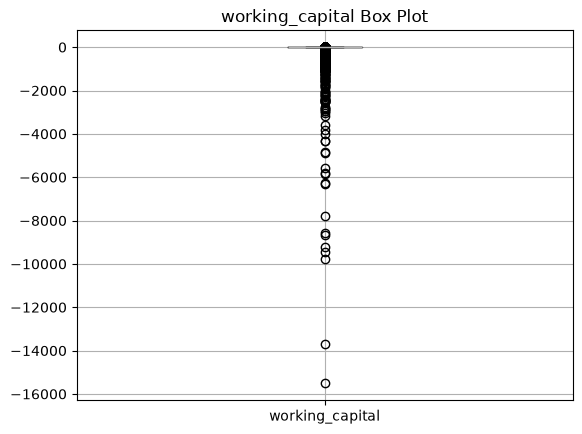

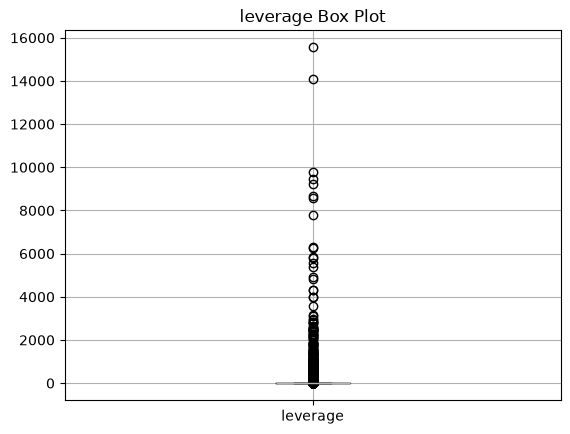

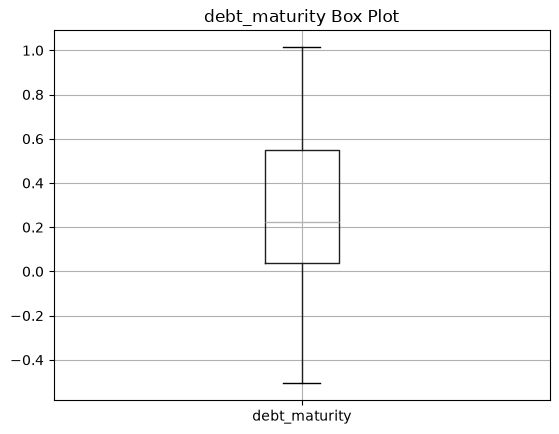

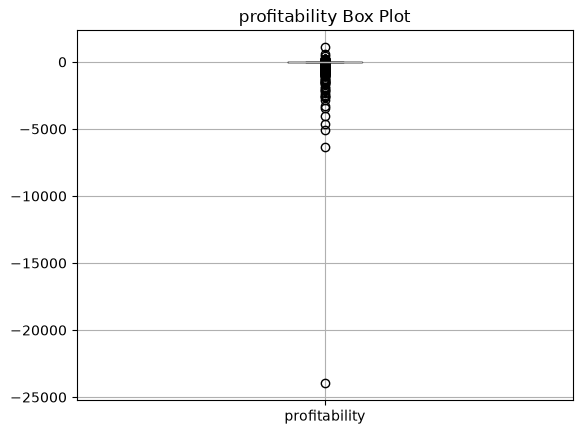

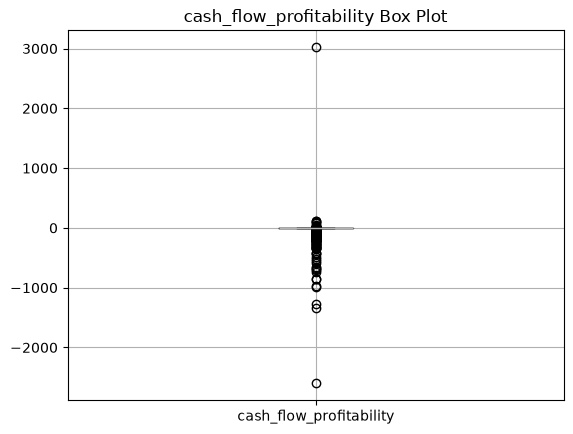

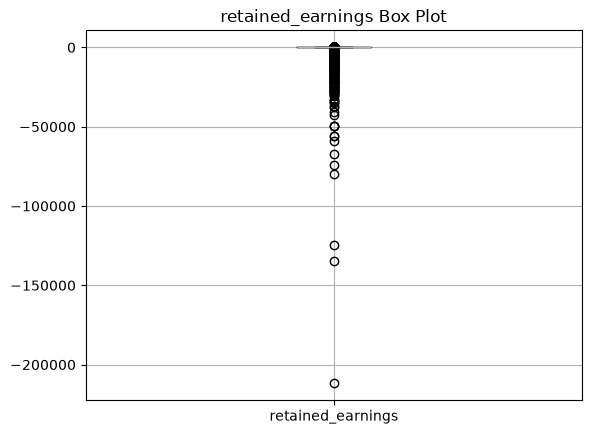

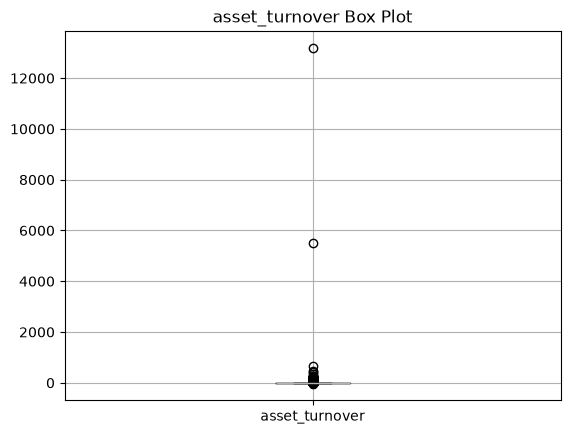

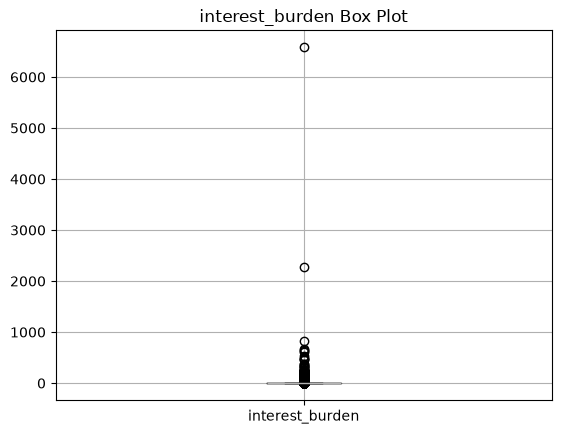

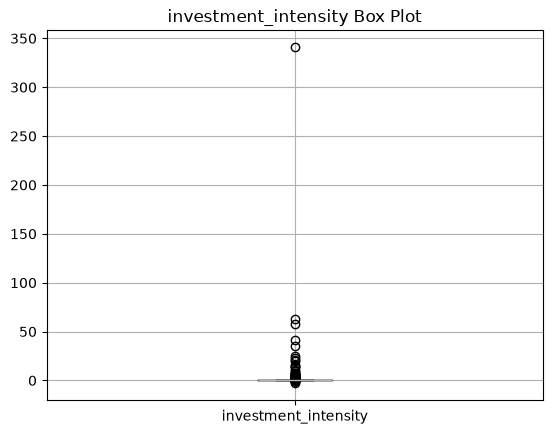

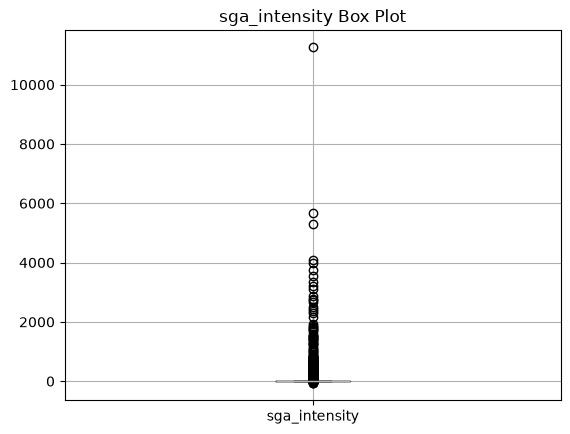

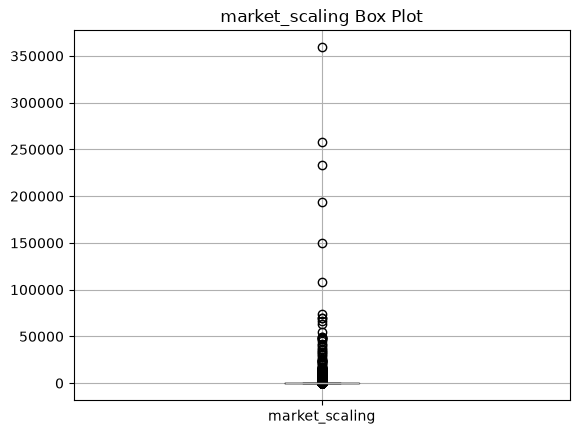

working_capital 1.0797818763123324
leverage 748.1162237790095
debt_maturity 1.0144200626959248
profitability 2936.0190010776428
cash_flow_profitability 7793.096226240028
retained_earnings 166.56063127846735
asset_turnover 2939.4237494511353
interest_burden 4544.241683241371
investment_intensity 929.2621516129178
sga_intensity 505.2863127178568
market_scaling 3995.3909421507547


'\nThe majority of accounting variables exhibited substantial outliers, with the maximum values exceeding the 99th percentile by more than a factor of 10 for almost all features. \nThis indicates the presence of a small number of extreme observations that may disproportionately influence model performance and therefore warrant treatment.\n'

In [ ]:
outlier_description = final[features].describe()
#print(outlier_description) #investigating outliers to be able to do the next steps 

#Boxlplots for better visualisation
for feature in features:
    final.boxplot(column=feature)
    plt.title(feature + " Box Plot")
    plt.show()

#final["act"].sort_values(ascending=False).head(20)
for feature in features:
    p99 = final[feature].quantile(0.99)
    count = (final[feature] > p99).sum()
    max = final[feature].max()
    print(feature, max/p99)

"""
The majority of accounting variables exhibited substantial outliers, with the maximum values exceeding the 99th percentile by more than a factor of 10 for almost all features. 
This indicates the presence of a small number of extreme observations that may disproportionately influence model performance and therefore warrant treatment.
"""


In [ ]:
#Now we windorize the extreme values for each feature by calculating the 1rst and 99th percentile & replace the extreme values with those calculations
#new dataframe just in case we need to go back
final_winsor = final.copy()
for feature in final_winsor[features]:
    p1 = final_winsor[feature].quantile(0.01)
    p99 = final_winsor[feature].quantile(0.99)
    final_winsor[feature] = final_winsor[feature].clip(lower= p1, upper=p99)

print(final["act"].quantile(0.01))
print(final["act"].quantile(0.99))
print(final_winsor["act"].max())
print(final_winsor["act"].min())
#Correct :)
final = final_winsor
final.to_csv("data/processed/final_dataset.csv", index=False)


0.001
22510.900750000186
210129.924
-7.76


In [ ]:
# Checking for data leakage (run on split dataframes, not feature matrices)
assert train["year"].max() < val["year"].min()
assert val["year"].max() < test["year"].min()

train_keys = set(zip(train["gvkey"], train["datadate"]))
val_keys   = set(zip(val["gvkey"], val["datadate"]))
test_keys  = set(zip(test["gvkey"], test["datadate"]))

assert train_keys.isdisjoint(val_keys)
assert train_keys.isdisjoint(test_keys)
assert val_keys.isdisjoint(test_keys)

In [ ]:

#check mean and std of scaled data, check for missing values and inf values
#display(X_train_scaled.describe().T[['mean', 'std']])

#display(X_train_scaled.isnull().sum().sort_values(ascending=False).head(20))

#display(np.isinf(X_train_scaled).sum().sort_values(ascending=False).head(20))
#X_train_scaled.shape #multicollinearity check

lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42) #Class imbalance handled here
lr.fit(X_train_scaled, y_train) #train model on scaled training data
y_pred = lr.predict(X_val_scaled)  #predict the target using the val dataset  (gives 0s and 1s) 
y_prob = lr.predict_proba(X_val_scaled)[:, 1] #predict the probability of the positibe class


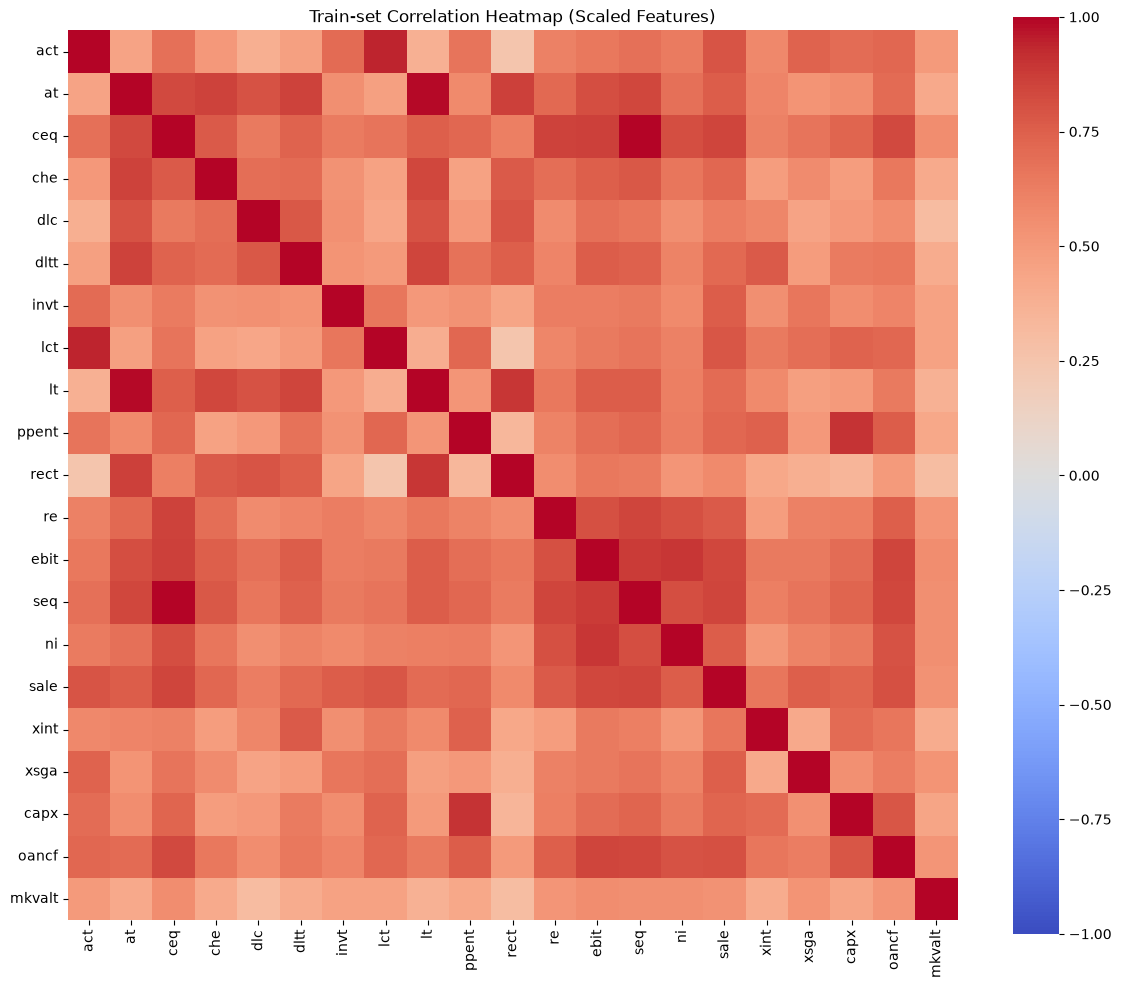

,var1,var2,abs_corr
55,ceq,seq,0.992341
29,at,lt,0.984470
7,act,lct,0.941535
207,ppent,capx,0.904944
178,lt,rect,0.896493
266,ebit,ni,0.893238
265,ebit,seq,0.875243
54,ceq,ebit,0.867183
31,at,rect,0.866994
24,at,che,0.859077


,feature,VIF
1,at,106.107400
13,seq,86.582519
8,lt,86.184772
2,ceq,77.221105
0,act,14.655397
7,lct,13.301256
12,ebit,11.599958
15,sale,9.030432
5,dltt,8.111445
9,ppent,8.107925


,feature,VIF
1,at,106.107400
13,seq,86.582519
8,lt,86.184772
2,ceq,77.221105
0,act,14.655397
7,lct,13.301256
12,ebit,11.599958
15,sale,9.030432
5,dltt,8.111445
9,ppent,8.107925


,feature,VIF
1,at,106.107400
13,seq,86.582519
8,lt,86.184772
2,ceq,77.221105
0,act,14.655397
7,lct,13.301256
12,ebit,11.599958


In [ ]:

X_train_df = pd.DataFrame(
    x_train,                 
    columns=accounting_features,
    index=x_train.index
)

# Correlation heatmap

corr = X_train_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True
)
plt.title("Train-set Correlation Heatmap (Scaled Features)")
plt.tight_layout()
plt.show()

# strongest absolute pairwise correlations
upper = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))
top_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "var1", "level_1": "var2", 0: "abs_corr"})
    .sort_values("abs_corr", ascending=False)
)
display(top_pairs.head(20))


# VIF table

vif_df = pd.DataFrame({
    "feature": X_train_df.columns,
    "VIF": [variance_inflation_factor(X_train_df.values, i)
            for i in range(X_train_df.shape[1])]
}).sort_values("VIF", ascending=False)

display(vif_df)

# Quick flags
display(vif_df[vif_df["VIF"] > 5])   # moderate concern
display(vif_df[vif_df["VIF"] > 10])  # serious concern

In [ ]:
#Validation
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_prob)
pr_auc = average_precision_score(y_val, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)
print("PR AUC:", pr_auc)  

print("**********************")
print("Confusion Matrix:")
cm = confusion_matrix(y_val, y_pred)
print(cm)

#Best combination of metrics for this model given by : 
best = None
for threshold in np.arange(0.05, 0.96, 0.01):
    y_hat = (y_prob >= threshold).astype(int)
    p = precision_score(y_val, y_hat , zero_division=0)
    f1 =f1_score(y_val,y_hat, zero_division=0)
    r = recall_score(y_val, y_hat, zero_division = 0)
    if best is None or f1 >= best[0]:
        best = (f1, p, r, threshold)

print("**********************")  
print("New values")
print("Best F1-Score/Precision/Recall/Threshold:", best)

best_threshold = best[3]
y_val_pred_best = (y_prob >= best_threshold).astype(int) #create vector with pred values 
cm2= confusion_matrix(y_val, y_val_pred_best)
print(cm2)

Accuracy: 0.904151999660715
Precision: 0.01578255151249452
Recall: 0.7058823529411765
F1-score: 0.030874785591766724
ROC-AUC: 0.8858018981138868
PR AUC: 0.03906438351761228
**********************
Confusion Matrix:
[[21283  2245]
 [   15    36]]
**********************
New values
Best F1-Score/Precision/Recall/Threshold: (0.053973013493253376, 0.02922077922077922, 0.35294117647058826, np.float64(0.8300000000000002))
[[22930   598]
 [   33    18]]
